In [45]:
from pathlib import Path
import csv
import math
import random
import statistics
from collections import Counter, defaultdict

DATA_FILE = Path("football_matches.csv")
RANDOM_SEED = 42

TEAM_PROFILES = {
    "Northbridge": (1.75, 0.85),
    "Riverside": (1.55, 1.00),
    "Kingsport": (1.48, 0.92),
    "Easton": (1.38, 1.05),
    "Lakeside": (1.28, 1.12),
    "Westhaven": (1.22, 1.18),
    "Hillcrest": (1.12, 1.20),
    "Pineford": (1.05, 1.28),
    "Brookfield": (0.98, 1.34),
    "Southgate": (0.92, 1.42),
    "Meadowvale": (0.86, 1.48),
    "Port Union": (0.78, 1.55),
}


def poisson_sample(rng, mean):
    """Draw one count from a Poisson distribution without external packages."""
    threshold = math.exp(-mean)
    product = 1.0
    count = 0
    while product > threshold:
        count += 1
        product *= rng.random()
    return count - 1


def create_dataset(path, match_count=6000, seed=RANDOM_SEED):
    """Create a reproducible, multi-season football match CSV."""
    rng = random.Random(seed)
    teams = list(TEAM_PROFILES)
    rows = []

    for match_id in range(1, match_count + 1):
        season = 2018 + ((match_id - 1) // 1000)
        home_team, away_team = rng.sample(teams, 2)
        home_attack, home_defense = TEAM_PROFILES[home_team]
        away_attack, away_defense = TEAM_PROFILES[away_team]
        weather = rng.choices(
            ["Clear", "Cloudy", "Rain", "Wind"],
            weights=[48, 27, 18, 7],
            k=1,
        )[0]
        weather_effect = {"Clear": 1.00, "Cloudy": 0.98, "Rain": 0.91, "Wind": 0.94}[weather]
        attendance = int(rng.normalvariate(28500, 6500))
        attendance = max(12000, min(42000, attendance))
        home_xg = max(0.15, (home_attack / away_defense) * 0.92 * weather_effect)
        away_xg = max(0.10, (away_attack / home_defense) * 0.76 * weather_effect)
        home_goals = poisson_sample(rng, home_xg)
        away_goals = poisson_sample(rng, away_xg)
        home_shots = max(home_goals + 2, int(rng.normalvariate(11 + home_xg * 2, 3)))
        away_shots = max(away_goals + 1, int(rng.normalvariate(9 + away_xg * 2, 3)))
        possession = max(32.0, min(68.0, rng.normalvariate(50 + (home_attack - away_attack) * 5, 6)))
        fouls = max(10, int(rng.normalvariate(23, 5)))
        referee = rng.choice(["A. Morgan", "B. Chen", "C. Patel", "D. Silva", "E. Okafor"])
        if home_goals > away_goals:
            result = "Home win"
        elif home_goals < away_goals:
            result = "Away win"
        else:
            result = "Draw"
        rows.append({
            "match_id": match_id,
            "season": season,
            "home_team": home_team,
            "away_team": away_team,
            "weather": weather,
            "attendance": attendance,
            "home_xg": round(home_xg, 2),
            "away_xg": round(away_xg, 2),
            "home_goals": home_goals,
            "away_goals": away_goals,
            "home_shots": home_shots,
            "away_shots": away_shots,
            "home_possession_pct": round(possession, 1),
            "fouls": fouls,
            "referee": referee,
            "result": result,
        })

    with path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
    return rows


def load_matches(path):
    """Read match records from a CSV into a list of dictionaries with numeric fields."""
    numeric_fields = {
        "match_id", "season", "attendance", "home_xg", "away_xg",
        "home_goals", "away_goals", "home_shots", "away_shots",
        "home_possession_pct", "fouls",
    }
    with path.open(newline="", encoding="utf-8") as csv_file:
        matches = []
        for row in csv.DictReader(csv_file):
            for field in numeric_fields:
                row[field] = float(row[field]) if "." in row[field] else int(row[field])
            matches.append(row)
    return matches


matches = create_dataset(DATA_FILE)
matches = load_matches(DATA_FILE)
print(f"Created {DATA_FILE} with {len(matches):,} matches and {len(matches[0]):,} columns.")
print("Columns:", ", ".join(matches[0]))
print("First match:", matches[0])

Created football_matches.csv with 6,000 matches and 16 columns.
Columns: match_id, season, home_team, away_team, weather, attendance, home_xg, away_xg, home_goals, away_goals, home_shots, away_shots, home_possession_pct, fouls, referee, result
First match: {'match_id': 1, 'season': 2018, 'home_team': 'Meadowvale', 'away_team': 'Riverside', 'weather': 'Clear', 'attendance': 25270, 'home_xg': 0.79, 'away_xg': 0.8, 'home_goals': 2, 'away_goals': 0, 'home_shots': 12, 'away_shots': 7, 'home_possession_pct': 49.9, 'fouls': 17, 'referee': 'A. Morgan', 'result': 'Home win'}


# Football Match Intelligence

## Goal

Use a reproducible match dataset to answer: **Which teams and conditions are associated with the strongest home performance?**

The dataset is synthetic but intentionally realistic enough for analysis: 6,000 matches across six seasons, 12 teams, match context, expected goals, shot counts, possession, referee, weather, attendance, and final result. The initial implementation uses Python's standard library only; pandas is reserved for Phase 4.

In [46]:
def mean(values):
    """Return a safe arithmetic mean for a non-empty sequence."""
    return statistics.mean(values) if values else 0.0


def summarize_seasons(records):
    """Calculate league-wide outcomes and scoring by season."""
    grouped = defaultdict(list)
    for match in records:
        grouped[match["season"]].append(match)

    summary = []
    for season, season_matches in sorted(grouped.items()):
        total_goals = [m["home_goals"] + m["away_goals"] for m in season_matches]
        summary.append({
            "season": season,
            "matches": len(season_matches),
            "home_win_pct": 100 * sum(m["result"] == "Home win" for m in season_matches) / len(season_matches),
            "draw_pct": 100 * sum(m["result"] == "Draw" for m in season_matches) / len(season_matches),
            "average_goals": mean(total_goals),
        })
    return summary


def summarize_teams(records):
    """Rank teams by home win rate, points per home match, and goal difference."""
    stats = defaultdict(lambda: {"matches": 0, "wins": 0, "draws": 0, "points": 0, "goals_for": 0, "goals_against": 0})
    for match in records:
        team = stats[match["home_team"]]
        team["matches"] += 1
        team["goals_for"] += match["home_goals"]
        team["goals_against"] += match["away_goals"]
        if match["result"] == "Home win":
            team["wins"] += 1
            team["points"] += 3
        elif match["result"] == "Draw":
            team["draws"] += 1
            team["points"] += 1

    ranked = []
    for team, values in stats.items():
        ranked.append({
            "team": team,
            "home_matches": values["matches"],
            "home_win_pct": 100 * values["wins"] / values["matches"],
            "points_per_match": values["points"] / values["matches"],
            "goal_difference": values["goals_for"] - values["goals_against"],
        })
    return sorted(ranked, key=lambda row: (row["points_per_match"], row["home_win_pct"]), reverse=True)


def summarize_weather(records):
    """Compare outcomes and scoring under each weather condition."""
    grouped = defaultdict(list)
    for match in records:
        grouped[match["weather"]].append(match)
    return sorted([
        {
            "weather": weather,
            "matches": len(weather_matches),
            "home_win_pct": 100 * sum(m["result"] == "Home win" for m in weather_matches) / len(weather_matches),
            "average_goals": mean([m["home_goals"] + m["away_goals"] for m in weather_matches]),
        }
        for weather, weather_matches in grouped.items()
    ], key=lambda row: row["home_win_pct"], reverse=True)


season_summary = summarize_seasons(matches)
team_summary = summarize_teams(matches)
weather_summary = summarize_weather(matches)

print("SEASON TRENDS")
for row in season_summary:
    print(f"{row['season']}: home wins {row['home_win_pct']:.1f}% | draws {row['draw_pct']:.1f}% | average goals {row['average_goals']:.2f}")

print("\nHOME PERFORMANCE LEADERBOARD")
for row in team_summary[:6]:
    print(f"{row['team']:<12} {row['home_win_pct']:5.1f}% wins | {row['points_per_match']:.2f} points/match | goal difference {row['goal_difference']:+d}")

print("\nWEATHER COMPARISON")
for row in weather_summary:
    print(f"{row['weather']:<7} {row['home_win_pct']:5.1f}% home wins | {row['average_goals']:.2f} goals/match | n={row['matches']}")

SEASON TRENDS
2018: home wins 35.2% | draws 38.6% | average goals 1.64
2019: home wins 37.5% | draws 34.2% | average goals 1.74
2020: home wins 35.6% | draws 36.2% | average goals 1.64
2021: home wins 36.7% | draws 34.1% | average goals 1.72
2022: home wins 36.8% | draws 34.8% | average goals 1.66
2023: home wins 38.1% | draws 35.0% | average goals 1.69

HOME PERFORMANCE LEADERBOARD
Riverside     45.9% wins | 1.68 points/match | goal difference +204
Westhaven     42.3% wins | 1.60 points/match | goal difference +140
Lakeside      41.9% wins | 1.57 points/match | goal difference +127
Northbridge   41.6% wins | 1.56 points/match | goal difference +152
Kingsport     39.3% wins | 1.47 points/match | goal difference +94
Easton        36.5% wins | 1.46 points/match | goal difference +79

WEATHER COMPARISON
Wind     37.7% home wins | 1.62 goals/match | n=422
Cloudy   37.0% home wins | 1.68 goals/match | n=1576
Clear    36.6% home wins | 1.74 goals/match | n=2883
Rain     35.9% home wins | 1.5

## Decision Support

A useful operational rule is to prioritize a home team when its historical home points per match is at least 1.50 and its goal difference is positive. This is descriptive evidence, not a causal claim: the synthetic data can reveal patterns but cannot establish why they occur.

In [47]:
def recommend_home_teams(ranked_teams, minimum_points=1.50):
    """Return teams meeting a transparent home-performance threshold."""
    if minimum_points <= 0:
        raise ValueError("minimum_points must be positive")
    return [
        row for row in ranked_teams
        if row["points_per_match"] >= minimum_points and row["goal_difference"] > 0
    ]


recommendations = recommend_home_teams(team_summary)
print("RECOMMENDED HOME TEAMS")
for row in recommendations:
    print(f"- {row['team']}: {row['points_per_match']:.2f} points/match, {row['goal_difference']:+d} goal difference")

best_condition = max(weather_summary, key=lambda row: row["home_win_pct"])
lowest_scoring_condition = min(weather_summary, key=lambda row: row["average_goals"])
print(f"\nRecommendation: investigate {recommendations[0]['team']} first for home-form decisions.")
print(f"Context: {best_condition['weather']} has the highest home-win rate, while {lowest_scoring_condition['weather']} has the lowest scoring rate.")

RECOMMENDED HOME TEAMS
- Riverside: 1.68 points/match, +204 goal difference
- Westhaven: 1.60 points/match, +140 goal difference
- Lakeside: 1.57 points/match, +127 goal difference
- Northbridge: 1.56 points/match, +152 goal difference

Recommendation: investigate Riverside first for home-form decisions.
Context: Wind has the highest home-win rate, while Rain has the lowest scoring rate.


## Visual Summary

The chart compares home-win rate by season and weather. It is intentionally built from the previously calculated dictionaries, keeping the visualization separate from data loading and aggregation.

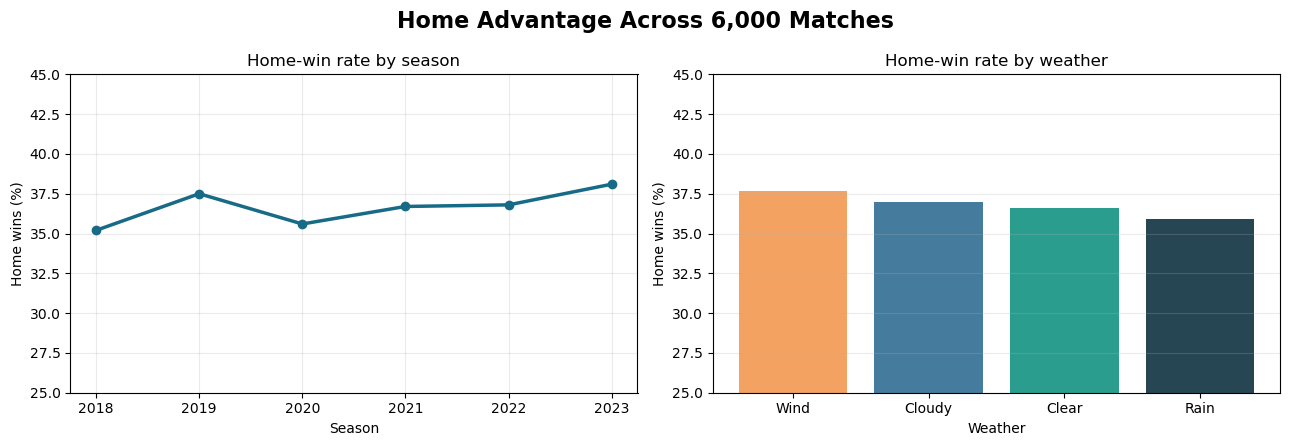

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Home Advantage Across 6,000 Matches", fontsize=16, fontweight="bold")

seasons = [row["season"] for row in season_summary]
home_win_rates = [row["home_win_pct"] for row in season_summary]
axes[0].plot(seasons, home_win_rates, marker="o", linewidth=2.5, color="#176b87")
axes[0].set_title("Home-win rate by season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Home wins (%)")
axes[0].set_ylim(25, 45)
axes[0].grid(alpha=0.25)

weather_names = [row["weather"] for row in weather_summary]
weather_rates = [row["home_win_pct"] for row in weather_summary]
axes[1].bar(weather_names, weather_rates, color=["#f4a261", "#457b9d", "#2a9d8f", "#264653"])
axes[1].set_title("Home-win rate by weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Home wins (%)")
axes[1].set_ylim(25, 45)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Interactive Terminal Report

Run the next cell to answer questions about the dataset. When the notebook is run as a Python program, the prompts and results appear directly in the terminal.

In [49]:
def find_team(team_name):
    """Find one team summary without case-sensitive matching."""
    requested_name = team_name.strip().lower()
    for row in team_summary:
        if row["team"].lower() == requested_name:
            return row
    return None


def print_team_report(team_name):
    """Print home-performance results for a selected team."""
    team = find_team(team_name)
    if team is None:
        print(f"No team named '{team_name}' was found.")
        print("Available teams:", ", ".join(row["team"] for row in team_summary))
        return
    print(f"\n{team['team']} HOME REPORT")
    print(f"Home matches:       {team['home_matches']}")
    print(f"Home-win rate:      {team['home_win_pct']:.1f}%")
    print(f"Points per match:   {team['points_per_match']:.2f}")
    print(f"Goal difference:    {team['goal_difference']:+d}")


def print_weather_report(weather_name):
    """Print results for a selected weather condition."""
    requested_weather = weather_name.strip().lower()
    weather = next((row for row in weather_summary if row["weather"].lower() == requested_weather), None)
    if weather is None:
        print(f"No weather condition named '{weather_name}' was found.")
        print("Available conditions:", ", ".join(row["weather"] for row in weather_summary))
        return
    print(f"\n{weather['weather'].upper()} MATCH REPORT")
    print(f"Matches:            {weather['matches']}")
    print(f"Home-win rate:      {weather['home_win_pct']:.1f}%")
    print(f"Average goals:      {weather['average_goals']:.2f}")


def print_season_report(season_text):
    """Print league results for a selected season."""
    try:
        season = int(season_text.strip())
    except ValueError:
        print("Please enter a season such as 2018 or 2023.")
        return
    result = next((row for row in season_summary if row["season"] == season), None)
    if result is None:
        print("That season is not in the dataset. Choose a season from 2018 through 2023.")
        return
    print(f"\n{season} SEASON REPORT")
    print(f"Matches:            {result['matches']}")
    print(f"Home-win rate:      {result['home_win_pct']:.1f}%")
    print(f"Draw rate:          {result['draw_pct']:.1f}%")
    print(f"Average goals:      {result['average_goals']:.2f}")


def interactive_report():
    """Ask terminal questions and print the matching analysis report."""
    print("=" * 52)
    print("FOOTBALL MATCH INTELLIGENCE")
    print("=" * 52)
    print("Choose a question:")
    print("1 - How did a team perform at home?")
    print("2 - How did weather affect home results?")
    print("3 - What happened in a particular season?")
    print("Q - Quit")
    print("\nTeams you can choose:")
    print(", ".join(row["team"] for row in team_summary))

    choice = input("\nEnter 1, 2, 3, or Q: ").strip().lower()
    if choice == "1":
        print_team_report(input("Which team? "))
    elif choice == "2":
        print_weather_report(input("Which weather condition? "))
    elif choice == "3":
        print_season_report(input("Which season? "))
    elif choice == "q":
        print("Goodbye.")
    else:
        print("Please choose 1, 2, 3, or Q.")


interactive_report()

FOOTBALL MATCH INTELLIGENCE
Choose a question:
1 - How did a team perform at home?
2 - How did weather affect home results?
3 - What happened in a particular season?
Q - Quit

Teams you can choose:
Riverside, Westhaven, Lakeside, Northbridge, Kingsport, Easton, Pineford, Hillcrest, Meadowvale, Southgate, Brookfield, Port Union

2019 SEASON REPORT
Matches:            1000
Home-win rate:      37.5%
Draw rate:          34.2%
Average goals:      1.74
